In [3]:
# Import Required Libraries
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [4]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
)

from config import DATASET_PATH

In [5]:
# Load the Trained Model
model = tf.keras.models.load_model(
    "../models/best_model.keras"
)

model.summary()

Model: "CropDiseaseEfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,075,671 (23.18 MB)

 Trainable params: 675,366 (2.58 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

 Optimizer params: 1,350,734 (5.15 MB)

In [6]:
# Load Validation Data
from src.preprocessing.data_loader import load_dataset

train_ds, val_ds, class_names = load_dataset()

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.


In [7]:
# Check Class Name
print(f"Total Classes: {len(class_names)}")

class_names

Total Classes: 38


['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [8]:
# Evaluate MOdel
loss, accuracy = model.evaluate(
    val_ds,
    verbose=1
)

print(f"Validation Loss     : {loss:.4f}")
print(f"Validation Accuracy : {accuracy:.4f}")

679/679 ━━━━━━━━━━━━━━━━━━━━ 494s 707ms/step - accuracy: 0.9637 - loss: 0.1162
Validation Loss     : 0.1162
Validation Accuracy : 0.9637


In [9]:
# Generate Predictions

In [10]:
y_true = []
y_pred = []

In [11]:
import numpy as np

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

In [12]:
y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Total Validation Samples:", len(y_true))

Total Validation Samples: 10861


In [13]:
print(y_true[:10])
print(y_pred[:10])

[15 15 15  4  3 14 35  8 37  3]
[15 15 15  4  3 14 35  8 37  3]


In [14]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9667    0.9206    0.9431       126
                                 Apple___Black_rot     1.0000    0.9924    0.9962       132
                          Apple___Cedar_apple_rust     1.0000    0.9818    0.9908        55
                                   Apple___healthy     0.9615    0.9878    0.9745       329
                               Blueberry___healthy     0.9866    1.0000    0.9933       295
          Cherry_(including_sour)___Powdery_mildew     1.0000    0.9871    0.9935       232
                 Cherry_(including_sour)___healthy     1.0000    0.9820    0.9909       167
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.9091    0.9259    0.9174       108
                       Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000       219
               Corn_(maize)___Northern_Leaf_Blight     0.9536    0.9487    0.95

In [15]:
from pathlib import Path

output_path = Path("../outputs")

output_path.mkdir(exist_ok=True)

with open(output_path / "classification_report.txt", "w") as f:
    f.write(report)

print("Classification report saved successfully!")

Classification report saved successfully!


In [16]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_true,
    y_pred
)

print(cm.shape)

(38, 38)


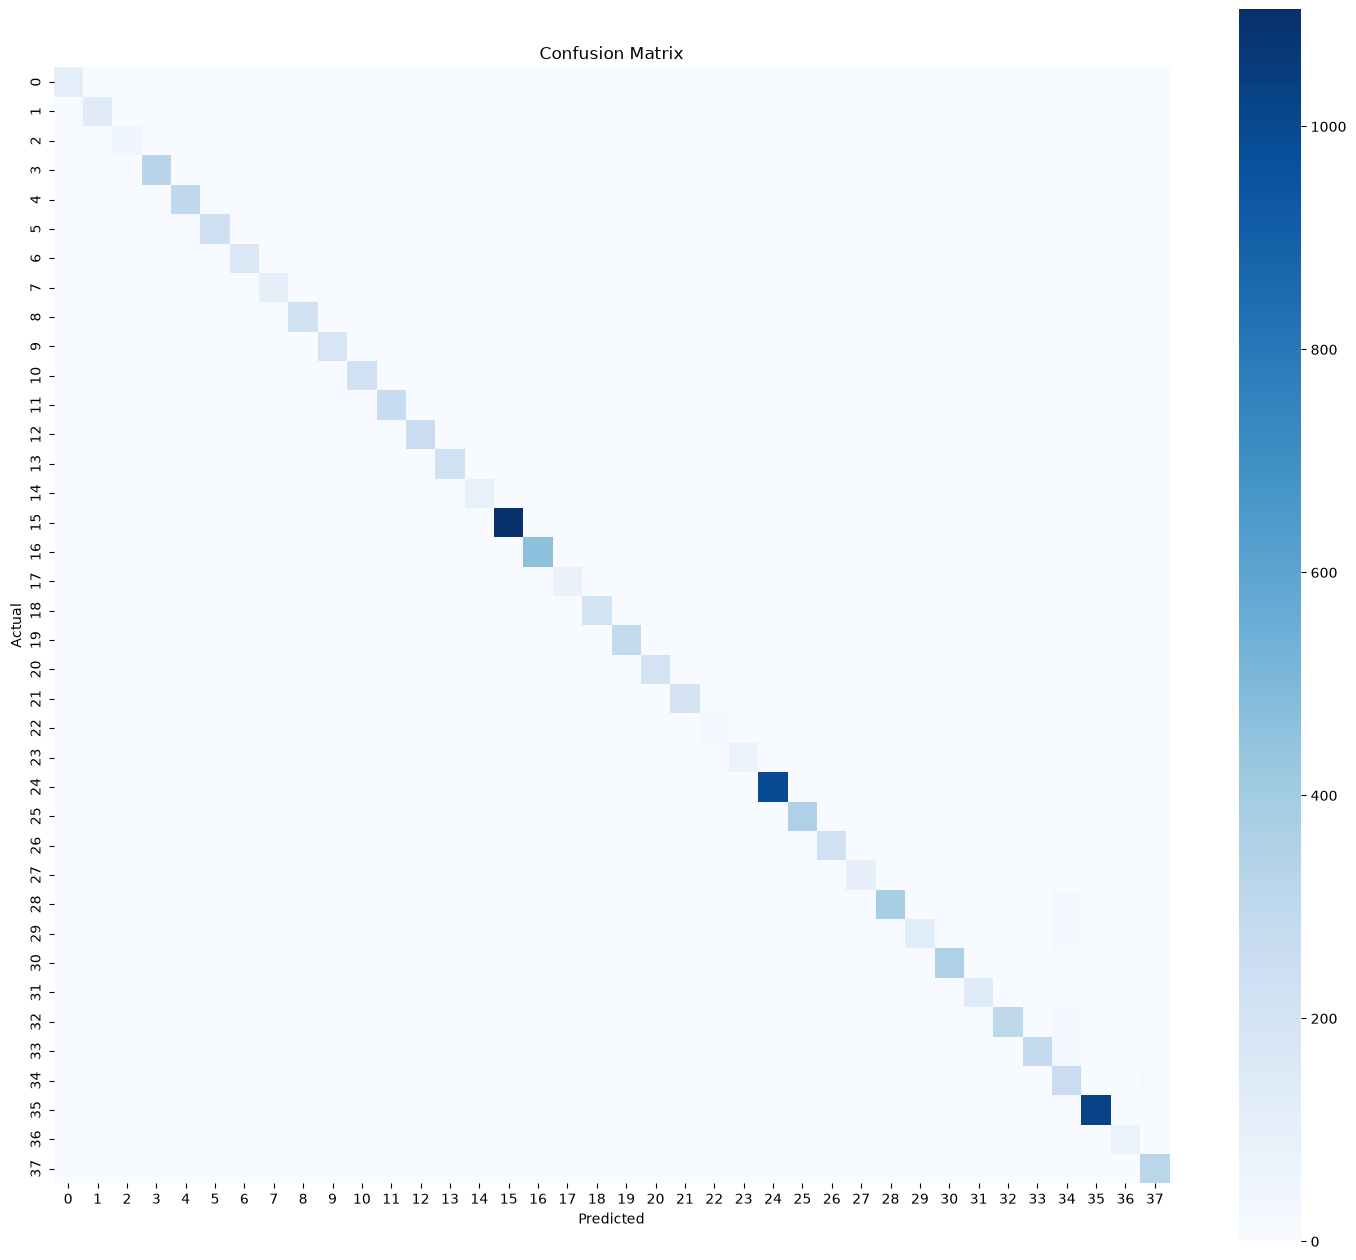

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm,
    cmap="Blues",
    square=True,
    cbar=True
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

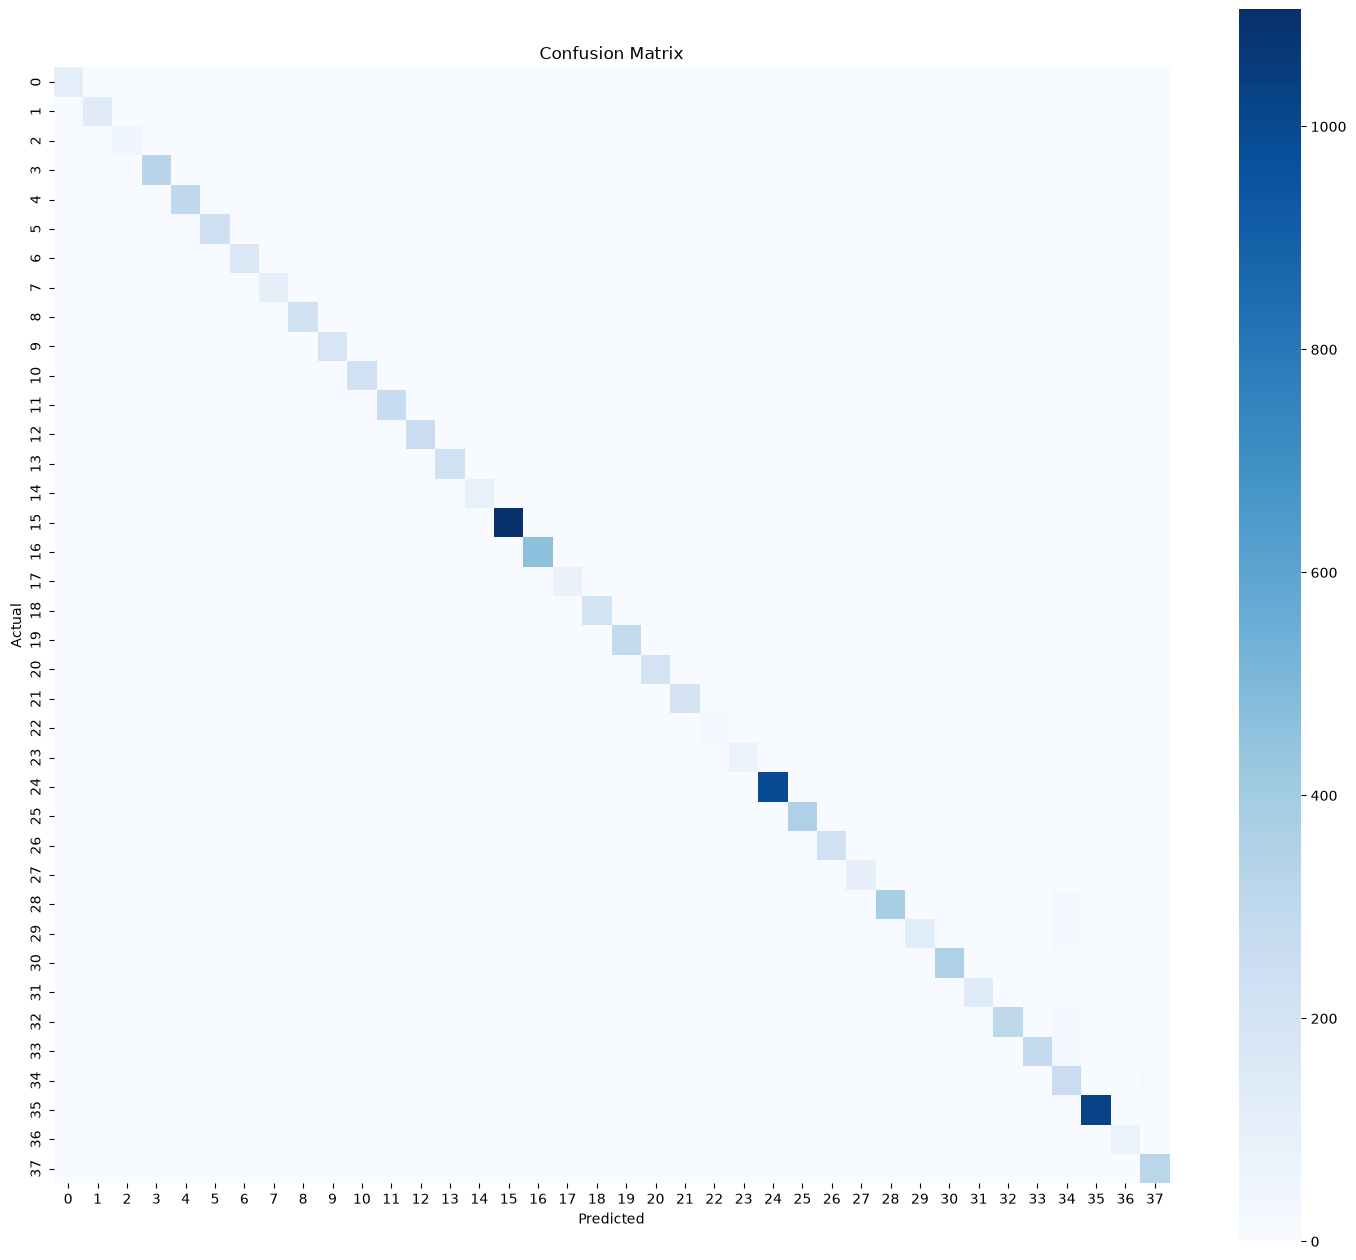

In [18]:
plt.figure(figsize=(18, 16))

sns.heatmap(
    cm,
    cmap="Blues",
    square=True,
    cbar=True
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig(
    "../outputs/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
# Detailed Evaluation Metrics

In [20]:
# Overall Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

accuracy = accuracy_score(y_true, y_pred)

precision = precision_score(
    y_true,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_true,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

Accuracy : 0.9637
Precision: 0.9681
Recall   : 0.9637
F1 Score : 0.9642


In [21]:
# Save Metrics
import pandas as pd

metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],
    "Value": [
        accuracy,
        precision,
        recall,
        f1
    ]
})

metrics

,Metric,Value
0,Accuracy,0.963723
1,Precision,0.968134
2,Recall,0.963723
3,F1 Score,0.964197


In [22]:
# Sve it in csv
metrics.to_csv(
    "../outputs/evaluation_metrics.csv",
    index=False
)

print("Evaluation metrics saved.")

Evaluation metrics saved.


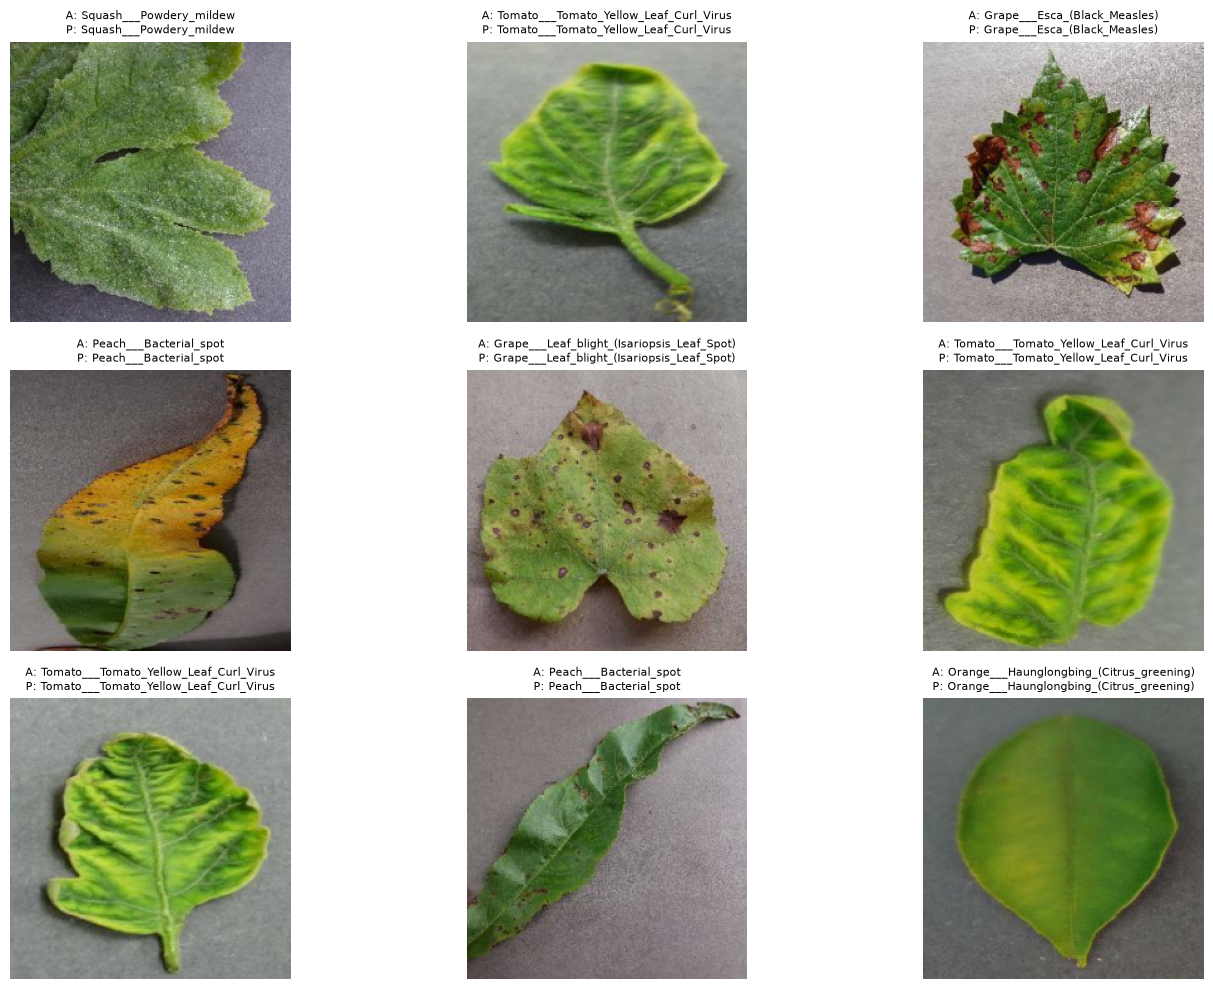

In [23]:
# Display Sample Predictions
import matplotlib.pyplot as plt

plt.figure(figsize=(15,10))

for images, labels in val_ds.take(1):

    predictions = model.predict(images, verbose=0)

    predicted = np.argmax(predictions, axis=1)

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        actual = class_names[labels[i]]

        pred = class_names[predicted[i]]

        plt.title(f"A: {actual}\nP: {pred}", fontsize=8)

        plt.axis("off")

plt.tight_layout()

plt.show()

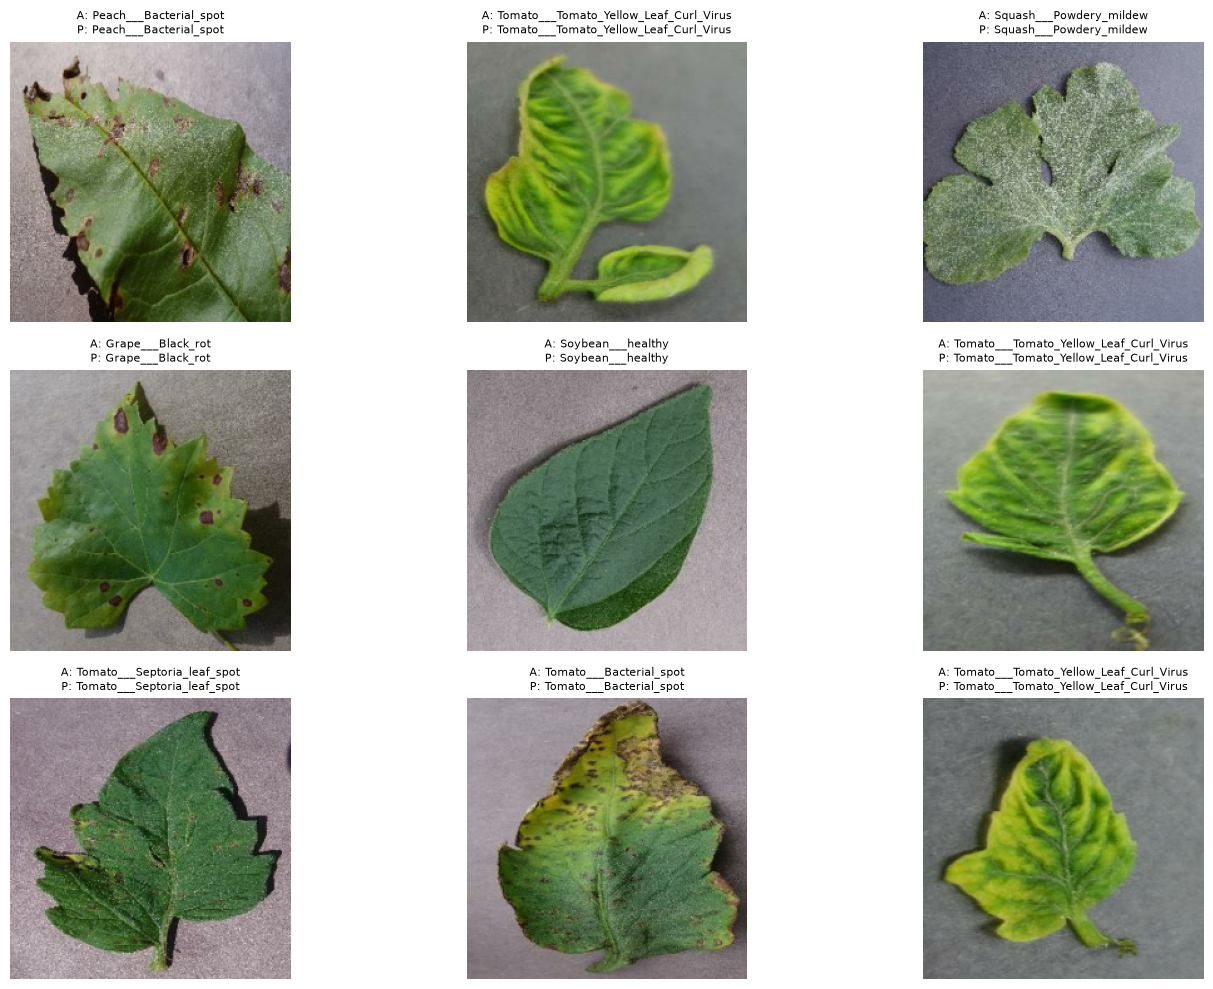

In [24]:
# Save the sample predictions
plt.figure(figsize=(15,10))

for images, labels in val_ds.take(1):

    predictions = model.predict(images, verbose=0)

    predicted = np.argmax(predictions, axis=1)

    for i in range(9):

        plt.subplot(3,3,i+1)

        plt.imshow(images[i].numpy().astype("uint8"))

        actual = class_names[labels[i]]

        pred = class_names[predicted[i]]

        plt.title(f"A: {actual}\nP: {pred}", fontsize=8)

        plt.axis("off")

plt.tight_layout()

plt.savefig(
    "../outputs/sample_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()